# SGP Denominator Investigation: Pitcher Rate-Stat Distortion

**Problem:** SGP denominators (standings gains per unit) don't volume-weight rate stats. A reliever with 60 IP and a 2.50 ERA gets the same ERA SGP score as a starter with 180 IP and a 2.50 ERA. This makes SGP overvalue relievers and collapses pitcher WAR correlation (~0).

**Key comparison:** ZAR converts rate stats to *marginal contributions* by multiplying `(player_rate - baseline) * IP`, so volume is baked in. SGP computes `(baseline - player_rate) / denominator` with no IP factor.

**Analysis plan:**
1. Show SGP denominator values and how they're computed
2. Compare SGP vs ZAR pitcher rankings — where do they disagree most?
3. Quantify reliever inflation: SP vs RP SGP scores by category
4. Simulate volume-weighted SGP and measure improvement
5. WAR correlation: SGP vs ZAR pitcher dollars

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

from fantasy_baseball_manager.db.connection import create_connection
from fantasy_baseball_manager.analysis_container import AnalysisContainer

conn = create_connection(Path("../data/fbm.db"))
container = AnalysisContainer(conn)

SEASON = 2024  # holdout season with actual results
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## 1. The Formulas Side by Side

**SGP rate-stat score** (ERA example, lower-is-better):
```
sgp_era = (baseline_era - player_era) / |sgp_denominator_era|
```
- No IP anywhere. A reliever with ERA 2.50 and a starter with ERA 2.50 get identical scores.

**ZAR rate-stat contribution** (ERA example):
```
zar_era = (baseline_era - player_era) * player_ip
```
- Multiplied by IP. The starter's contribution is 3x the reliever's because they pitch 3x the innings.

## 2. Load SGP and ZAR-Reformed Pitcher Valuations (2024 Holdout)

In [2]:
# Load pitcher valuations from both systems (holdout version = steamer projections)
sgp_pitchers = pd.read_sql(
    """
    SELECT v.player_id, p.name_first || ' ' || p.name_last as name,
           v.position, v.value, v.rank, v.category_scores_json
    FROM valuation v
    JOIN player p ON v.player_id = p.id
    WHERE v.system = 'sgp' AND v.version = 'holdout'
      AND v.season = ? AND v.player_type = 'pitcher'
    ORDER BY v.value DESC
""",
    conn,
    params=[SEASON],
)
sgp_pitchers["system"] = "sgp"

zar_pitchers = pd.read_sql(
    """
    SELECT v.player_id, p.name_first || ' ' || p.name_last as name,
           v.position, v.value, v.rank, v.category_scores_json
    FROM valuation v
    JOIN player p ON v.player_id = p.id
    WHERE v.system = 'zar-reformed' AND v.version = 'holdout'
      AND v.season = ? AND v.player_type = 'pitcher'
    ORDER BY v.value DESC
""",
    conn,
    params=[SEASON],
)
zar_pitchers["system"] = "zar-reformed"

# Parse category scores JSON
import json

for df in [sgp_pitchers, zar_pitchers]:
    scores = df["category_scores_json"].apply(json.loads)
    for cat in ["era", "whip", "so", "w", "sv+hld"]:
        df[f"cat_{cat}"] = scores.apply(lambda s, c=cat: s.get(c, 0.0))

print(f"SGP pitchers: {len(sgp_pitchers)}, ZAR-reformed pitchers: {len(zar_pitchers)}")
print(f"\nSGP top 10:")
sgp_pitchers[["name", "position", "value", "rank", "cat_era", "cat_whip", "cat_so", "cat_w", "cat_sv+hld"]].head(10)

SGP pitchers: 586, ZAR-reformed pitchers: 369

SGP top 10:


,name,position,value,rank,cat_era,cat_whip,cat_so,cat_w,cat_sv+hld
0,Edwin Díaz,RP,110.33,1,1.743942,16.558653,2.557236,1.099080,4.489683
1,Spencer Strider,P,104.88,2,1.238064,14.309890,6.887509,4.244323,0.000000
2,Mason Miller,RP,72.56,5,1.523865,13.515817,2.514124,1.077713,3.340608
3,Kevin Gausman,P,67.33,6,0.916151,11.595837,5.918820,3.797600,0.000000
4,Pete Fairbanks,RP,65.63,7,1.478862,12.101763,2.397234,1.095046,4.077323
5,Jhoan Durán,RP,64.28,9,1.951690,12.681987,2.033554,0.953923,3.369590
6,Andrés Muñoz,RP,61.08,10,1.613397,11.825182,2.261932,1.067833,3.842746
7,George Kirby,P,60.15,11,0.684783,12.180542,4.910658,3.601174,0.000000
8,Tarik Skubal,P,57.10,13,1.057563,11.335034,5.293566,3.329977,0.000000
9,Zack Wheeler,P,52.08,14,0.773528,10.500869,5.319790,3.826012,0.000000


In [3]:
# Load projections to get IP for each pitcher (steamer, 2024)
projections = pd.read_sql(
    """
    SELECT player_id, ip, era, whip, so, w, sv, hld, er, bb, h
    FROM projection
    WHERE season = ? AND system = 'steamer' AND ip > 0
""",
    conn,
    params=[SEASON],
)

# Classify as SP/RP based on projected GS (if available) or position in valuation
proj_gs = pd.read_sql(
    """
    SELECT player_id, gs FROM projection
    WHERE season = ? AND system = 'steamer'
""",
    conn,
    params=[SEASON],
)
projections = projections.merge(proj_gs[["player_id", "gs"]], on="player_id", how="left")
projections["pitcher_type"] = np.where(projections["gs"] >= 5, "SP", "RP")

# Merge IP and pitcher type into valuation dataframes
for df in [sgp_pitchers, zar_pitchers]:
    df_merged = df.merge(projections[["player_id", "ip", "pitcher_type", "era", "whip"]], on="player_id", how="left")
    df["ip"] = df_merged["ip"]
    df["pitcher_type"] = df_merged["pitcher_type"]
    df["proj_era"] = df_merged["era"]
    df["proj_whip"] = df_merged["whip"]

print("SGP pitcher type distribution:")
print(sgp_pitchers.groupby("pitcher_type")["value"].describe()[["count", "mean", "min", "max"]].round(1))
print("\nZAR pitcher type distribution:")
print(zar_pitchers.groupby("pitcher_type")["value"].describe()[["count", "mean", "min", "max"]].round(1))

SGP pitcher type distribution:
              count  mean  min    max
pitcher_type                         
RP            369.0   1.9  0.0  110.3
SP            217.0   4.0  0.0  104.9

ZAR pitcher type distribution:
              count  mean  min   max
pitcher_type                        
RP            167.0   0.4  0.0  16.6
SP            202.0   7.4  0.0  89.8


## 3. Biggest SGP vs ZAR Ranking Disagreements

Where does SGP rank a pitcher much higher than ZAR, or vice versa?

In [4]:
# Merge SGP and ZAR on player_id, focus on players valued > $0 in at least one system
merged = sgp_pitchers[
    [
        "player_id",
        "name",
        "value",
        "rank",
        "ip",
        "pitcher_type",
        "proj_era",
        "proj_whip",
        "cat_era",
        "cat_whip",
        "cat_so",
        "cat_w",
        "cat_sv+hld",
    ]
].merge(
    zar_pitchers[["player_id", "value", "rank", "cat_era", "cat_whip", "cat_so", "cat_w", "cat_sv+hld"]],
    on="player_id",
    suffixes=("_sgp", "_zar"),
    how="outer",
)
merged = merged[(merged["value_sgp"] > 0) | (merged["value_zar"] > 0)].copy()
merged["rank_diff"] = merged["rank_zar"] - merged["rank_sgp"]  # positive = SGP ranks higher
merged["value_diff"] = merged["value_sgp"] - merged["value_zar"]

print("Top 15 pitchers SGP overvalues vs ZAR (SGP ranks much higher):")
overvalued = merged.nlargest(15, "value_diff")
overvalued[
    ["name", "pitcher_type", "ip", "proj_era", "value_sgp", "value_zar", "value_diff", "cat_era_sgp", "cat_whip_sgp"]
].round(2)

Top 15 pitchers SGP overvalues vs ZAR (SGP ranks much higher):


,name,pitcher_type,ip,proj_era,value_sgp,value_zar,value_diff,cat_era_sgp,cat_whip_sgp
0,Edwin Díaz,RP,64.00,2.78,110.33,16.56,93.77,1.74,16.56
55,Mason Miller,RP,68.00,2.96,72.56,13.04,59.52,1.52,13.52
289,Pete Fairbanks,RP,66.00,2.99,65.63,9.98,55.65,1.48,12.10
411,Andrés Muñoz,RP,64.00,2.88,61.08,8.86,52.22,1.61,11.83
574,Josh Hader,RP,63.00,3.34,39.46,2.76,36.70,1.05,9.44
575,Emmanuel Clase,RP,66.00,3.17,36.09,0.00,36.09,1.26,9.15
229,Ryan Helsley,RP,65.00,3.21,36.50,3.55,32.95,1.21,9.04
219,Raisel Iglesias,RP,66.00,3.62,32.89,0.00,32.89,0.70,9.20
187,Adbert Alzolay,RP,67.00,3.65,25.13,0.00,25.13,0.66,8.65
414,Matt Strahm,RP,70.00,3.56,24.20,2.19,22.01,0.77,10.48


In [5]:
print("Top 15 pitchers ZAR overvalues vs SGP (ZAR ranks much higher):")
undervalued = merged.nsmallest(15, "value_diff")
undervalued[
    ["name", "pitcher_type", "ip", "proj_era", "value_sgp", "value_zar", "value_diff", "cat_era_sgp", "cat_whip_sgp"]
].round(2)

Top 15 pitchers ZAR overvalues vs SGP (ZAR ranks much higher):


,name,pitcher_type,ip,proj_era,value_sgp,value_zar,value_diff,cat_era_sgp,cat_whip_sgp
88,Framber Valdez,SP,195.50,3.39,11.72,49.11,-37.39,0.98,5.32
279,Blake Snell,SP,167.15,3.53,0.00,32.17,-32.17,0.80,4.21
419,Logan Webb,SP,201.38,3.50,12.27,42.66,-30.39,0.84,6.36
515,Max Fried,SP,184.58,3.59,7.34,37.40,-30.06,0.73,5.72
490,DL Hall,SP,134.32,3.66,0.00,28.99,-28.99,0.65,2.89
445,Mike King,SP,149.09,3.86,0.00,26.97,-26.97,0.39,2.79
148,Corbin Burnes,SP,197.17,3.78,11.86,37.77,-25.91,0.50,5.94
358,Jesús Luzardo,SP,180.78,3.76,5.03,30.88,-25.85,0.51,5.56
147,Justin Steele,SP,181.11,3.71,0.00,25.26,-25.26,0.59,4.74
567,Kenta Maeda,SP,145.41,4.11,0.00,24.26,-24.26,0.08,6.02


## 4. Reliever Inflation: SP vs RP Category Score Breakdown

Break down average SGP scores by category for SP vs RP. The rate-stat categories (ERA, WHIP) should show RP getting disproportionate credit relative to their IP.

In [6]:
# Average category SGP scores for SP vs RP (top 100 pitchers by SGP value)
top_sgp = sgp_pitchers[sgp_pitchers["value"] > 0].copy()
cats = ["cat_era", "cat_whip", "cat_so", "cat_w", "cat_sv+hld"]

sgp_by_type = top_sgp.groupby("pitcher_type")[cats + ["value", "ip"]].mean()
sgp_by_type.columns = [c.replace("cat_", "") for c in cats] + ["avg_value", "avg_ip"]
print("Average SGP scores by pitcher type (valued pitchers only):")
print(sgp_by_type.round(3))

print("\n--- Rate stat contribution as % of total composite ---")
for pt in ["SP", "RP"]:
    subset = top_sgp[top_sgp["pitcher_type"] == pt]
    if len(subset) == 0:
        continue
    rate_mean = subset[["cat_era", "cat_whip"]].sum(axis=1).mean()
    count_mean = subset[["cat_so", "cat_w", "cat_sv+hld"]].sum(axis=1).mean()
    total = rate_mean + count_mean
    if total != 0:
        print(
            f"{pt}: rate stats = {rate_mean:.2f} ({rate_mean / total * 100:.0f}%), "
            f"counting stats = {count_mean:.2f} ({count_mean / total * 100:.0f}%), "
            f"avg IP = {subset['ip'].mean():.0f}"
        )

Average SGP scores by pitcher type (valued pitchers only):
                era   whip     so      w  sv+hld  avg_value   avg_ip
pitcher_type                                                        
RP            1.122  9.233  2.154  1.045   3.272     29.161   64.667
SP            0.600  8.772  5.018  3.369   0.003     29.660  174.575

--- Rate stat contribution as % of total composite ---
SP: rate stats = 9.37 (53%), counting stats = 8.39 (47%), avg IP = 175
RP: rate stats = 10.36 (62%), counting stats = 6.47 (38%), avg IP = 65


In [ ]:
# Visualize: SGP category scores by pitcher type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SGP category breakdown
cat_labels = ["ERA", "WHIP", "SO", "W", "SV+HLD"]
for _i, pt in enumerate(["SP", "RP"]):
    subset = top_sgp[top_sgp["pitcher_type"] == pt]
    means = [subset[c].mean() for c in cats]
    colors = ["#e74c3c" if "era" in c or "whip" in c else "#3498db" for c in cats]
    axes[0].barh([f"{lab} ({pt})" for lab in cat_labels], means, color=colors, alpha=0.7 if pt == "SP" else 0.5)

axes[0].set_xlabel("Average SGP Score")
axes[0].set_title("SGP Category Scores: SP vs RP\n(Red = rate stats, Blue = counting stats)")
axes[0].axvline(x=0, color="black", linewidth=0.5)

# Same for ZAR
top_zar = zar_pitchers[zar_pitchers["value"] > 0].copy()
for _i, pt in enumerate(["SP", "RP"]):
    subset = top_zar[top_zar["pitcher_type"] == pt]
    means = [subset[c].mean() for c in cats]
    colors = ["#e74c3c" if "era" in c or "whip" in c else "#3498db" for c in cats]
    axes[1].barh([f"{lab} ({pt})" for lab in cat_labels], means, color=colors, alpha=0.7 if pt == "SP" else 0.5)

axes[1].set_xlabel("Average Z-Score")
axes[1].set_title("ZAR Category Scores: SP vs RP\n(Red = rate stats, Blue = counting stats)")
axes[1].axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("../notebooks/sgp_category_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. The Core Problem: ERA SGP per IP

If SGP were "fair", a pitcher's ERA contribution should scale with their IP (since a team's ERA is IP-weighted). Let's plot ERA SGP score vs IP for both systems.

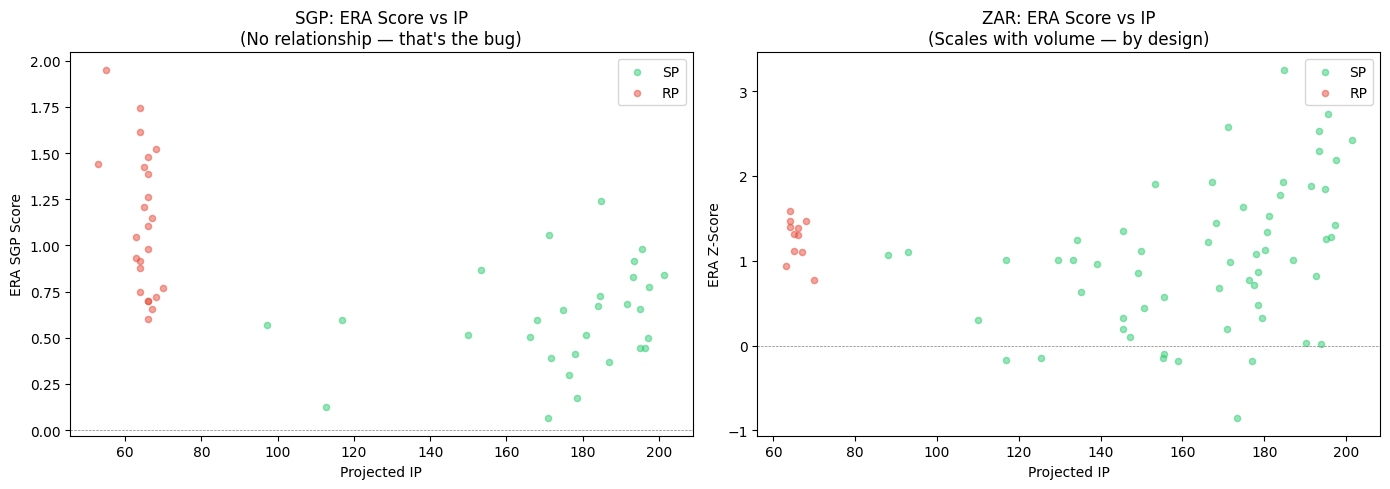

SGP ERA score ~ IP correlation: ρ = -0.541 (p = 0.0000)
ZAR ERA score ~ IP correlation: ρ = 0.229 (p = 0.0568)


In [8]:
# ERA SGP vs IP — should show SGP is flat w.r.t. IP, while ZAR scales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SGP
for pt, color in [("SP", "#2ecc71"), ("RP", "#e74c3c")]:
    mask = sgp_pitchers["pitcher_type"] == pt
    subset = sgp_pitchers[mask & (sgp_pitchers["value"] > 0)]
    axes[0].scatter(subset["ip"], subset["cat_era"], alpha=0.5, label=pt, color=color, s=20)
axes[0].set_xlabel("Projected IP")
axes[0].set_ylabel("ERA SGP Score")
axes[0].set_title("SGP: ERA Score vs IP\n(No relationship — that's the bug)")
axes[0].legend()
axes[0].axhline(y=0, color="gray", linewidth=0.5, linestyle="--")

# ZAR
for pt, color in [("SP", "#2ecc71"), ("RP", "#e74c3c")]:
    mask = zar_pitchers["pitcher_type"] == pt
    subset = zar_pitchers[mask & (zar_pitchers["value"] > 0)]
    axes[1].scatter(subset["ip"], subset["cat_era"], alpha=0.5, label=pt, color=color, s=20)
axes[1].set_xlabel("Projected IP")
axes[1].set_ylabel("ERA Z-Score")
axes[1].set_title("ZAR: ERA Score vs IP\n(Scales with volume — by design)")
axes[1].legend()
axes[1].axhline(y=0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("../notebooks/sgp_era_vs_ip.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation of ERA score with IP
for label, df in [("SGP", sgp_pitchers), ("ZAR", zar_pitchers)]:
    valued = df[df["value"] > 0].dropna(subset=["ip", "cat_era"])
    r, p = scipy_stats.spearmanr(valued["ip"], valued["cat_era"])
    print(f"{label} ERA score ~ IP correlation: ρ = {r:.3f} (p = {p:.4f})")

## 6. Simulate Volume-Weighted SGP

What if we modified SGP to weight rate-stat contributions by IP? This is the "IP-weighted SGP" variant:

```
sgp_era_weighted = (baseline_era - player_era) / |denom| * (player_ip / league_avg_ip_per_slot)
```

This scales each pitcher's rate-stat SGP by their IP share, similar to how ZAR uses marginal contributions.

In [9]:
# Simulate IP-weighted SGP for rate stats
# We'll recompute SGP scores from scratch using projections

# Get league average IP per pitcher slot for normalization
# h2h league: 8 pitcher roster spots * 12 teams = 96 slots
# Total league IP ≈ sum of all projected IP for draftable pitchers / 12 teams
valued_sgp = sgp_pitchers[sgp_pitchers["value"] > 0].dropna(subset=["ip"])
avg_ip_per_slot = valued_sgp["ip"].mean()
print(f"Average IP per valued pitcher slot: {avg_ip_per_slot:.1f}")

# IP weight = player_ip / avg_ip_per_slot (capped at some reasonable max)
sgp_pitchers["ip_weight"] = (sgp_pitchers["ip"] / avg_ip_per_slot).clip(upper=2.0)

# Recompute weighted rate stats (ERA, WHIP get multiplied by IP weight)
sgp_pitchers["cat_era_weighted"] = sgp_pitchers["cat_era"] * sgp_pitchers["ip_weight"]
sgp_pitchers["cat_whip_weighted"] = sgp_pitchers["cat_whip"] * sgp_pitchers["ip_weight"]

# New composite = weighted rate stats + original counting stats
sgp_pitchers["composite_weighted"] = (
    sgp_pitchers["cat_era_weighted"]
    + sgp_pitchers["cat_whip_weighted"]
    + sgp_pitchers["cat_so"]
    + sgp_pitchers["cat_w"]
    + sgp_pitchers["cat_sv+hld"]
)
sgp_pitchers["composite_original"] = sgp_pitchers[cats].sum(axis=1)

# Compare SP vs RP under both schemes
print("\nOriginal SGP composite (mean by pitcher type, valued only):")
print(
    sgp_pitchers[sgp_pitchers["value"] > 0]
    .groupby("pitcher_type")[["composite_original", "composite_weighted", "ip"]]
    .mean()
    .round(3)
)

print("\nOriginal SGP: RP composite / SP composite ratio:")
rp_orig = sgp_pitchers[(sgp_pitchers["value"] > 0) & (sgp_pitchers["pitcher_type"] == "RP")][
    "composite_original"
].mean()
sp_orig = sgp_pitchers[(sgp_pitchers["value"] > 0) & (sgp_pitchers["pitcher_type"] == "SP")][
    "composite_original"
].mean()
print(f"  {rp_orig / sp_orig:.2f}x")

print("\nWeighted SGP: RP composite / SP composite ratio:")
rp_wt = sgp_pitchers[(sgp_pitchers["value"] > 0) & (sgp_pitchers["pitcher_type"] == "RP")]["composite_weighted"].mean()
sp_wt = sgp_pitchers[(sgp_pitchers["value"] > 0) & (sgp_pitchers["pitcher_type"] == "SP")]["composite_weighted"].mean()
print(f"  {rp_wt / sp_wt:.2f}x")

Average IP per valued pitcher slot: 124.8

Original SGP composite (mean by pitcher type, valued only):
              composite_original  composite_weighted       ip
pitcher_type                                                 
RP                        16.827              11.821   64.667
SP                        17.763              21.436  174.575

Original SGP: RP composite / SP composite ratio:
  0.95x

Weighted SGP: RP composite / SP composite ratio:
  0.55x


## 7. WAR Correlation: SGP vs ZAR vs IP-Weighted SGP

The ultimate test: which system's dollar values better predict actual pitcher WAR?

In [10]:
# Load actual pitching WAR for 2024
actual_war = pd.read_sql(
    """
    SELECT player_id, war, ip as actual_ip, era as actual_era, gs as actual_gs
    FROM pitching_stats
    WHERE season = ? AND source = 'fangraphs'
""",
    conn,
    params=[SEASON],
)

# Merge with SGP valuations
sgp_war = sgp_pitchers.merge(actual_war, on="player_id", how="inner")
zar_war = zar_pitchers.merge(actual_war, on="player_id", how="inner")

# Filter to pitchers with meaningful playing time
min_ip = 20
sgp_war_filtered = sgp_war[sgp_war["actual_ip"] >= min_ip]
zar_war_filtered = zar_war[zar_war["actual_ip"] >= min_ip]

print(f"Pitchers with >= {min_ip} actual IP and valuations:")
print(f"  SGP: {len(sgp_war_filtered)}, ZAR: {len(zar_war_filtered)}")

# Compute correlations for all three systems
results = {}
for label, df in [("SGP (original)", sgp_war_filtered), ("ZAR-reformed", zar_war_filtered)]:
    valued = df[df["value"] > 0]
    r_all, _ = scipy_stats.spearmanr(df["value"], df["war"])
    r_valued, _ = scipy_stats.spearmanr(valued["value"], valued["war"]) if len(valued) > 5 else (float("nan"), 0)
    results[label] = {"ρ (all)": r_all, "ρ (valued only)": r_valued, "n": len(df), "n_valued": len(valued)}

# IP-weighted SGP correlation
sgp_war_filtered = sgp_war_filtered.copy()
sgp_war_filtered["composite_weighted"] = (
    sgp_war_filtered["cat_era"] * sgp_war_filtered["ip_weight"]
    + sgp_war_filtered["cat_whip"] * sgp_war_filtered["ip_weight"]
    + sgp_war_filtered["cat_so"]
    + sgp_war_filtered["cat_w"]
    + sgp_war_filtered["cat_sv+hld"]
)
r_weighted, _ = scipy_stats.spearmanr(sgp_war_filtered["composite_weighted"], sgp_war_filtered["war"])
r_weighted_top, _ = scipy_stats.spearmanr(
    sgp_war_filtered.nlargest(96, "composite_weighted")["composite_weighted"],
    sgp_war_filtered.nlargest(96, "composite_weighted")["war"],
)
results["SGP (IP-weighted)"] = {
    "ρ (all)": r_weighted,
    "ρ (valued only)": r_weighted_top,
    "n": len(sgp_war_filtered),
    "n_valued": 96,
}

print("\nPitcher WAR Correlation Comparison:")
print(pd.DataFrame(results).T.round(3))

Pitchers with >= 20 actual IP and valuations:
  SGP: 436, ZAR: 324

Pitcher WAR Correlation Comparison:
                   ρ (all)  ρ (valued only)      n  n_valued
SGP (original)       0.323            0.377  436.0      49.0
ZAR-reformed         0.419            0.458  324.0      66.0
SGP (IP-weighted)    0.378            0.572  436.0      96.0


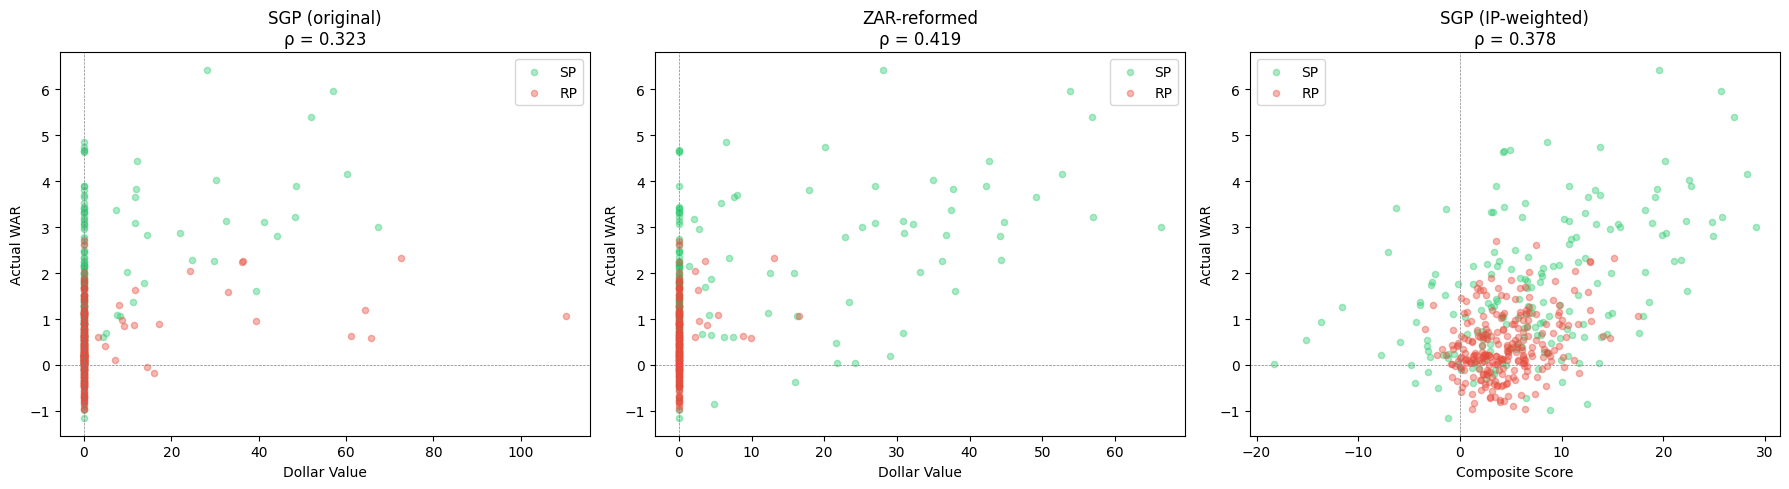

In [11]:
# Scatter plots: Value vs WAR for each system
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, df, val_col) in zip(
    axes,
    [
        ("SGP (original)", sgp_war_filtered, "value"),
        ("ZAR-reformed", zar_war_filtered, "value"),
        ("SGP (IP-weighted)", sgp_war_filtered, "composite_weighted"),
    ],
):
    for pt, color in [("SP", "#2ecc71"), ("RP", "#e74c3c")]:
        mask = df["pitcher_type"] == pt
        ax.scatter(df.loc[mask, val_col], df.loc[mask, "war"], alpha=0.4, label=pt, color=color, s=20)

    r, _ = scipy_stats.spearmanr(df[val_col], df["war"])
    ax.set_xlabel("Dollar Value" if val_col == "value" else "Composite Score")
    ax.set_ylabel("Actual WAR")
    ax.set_title(f"{label}\nρ = {r:.3f}")
    ax.legend()
    ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(x=0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.savefig("../notebooks/sgp_war_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Dollar Distribution Shape

Compare how top-heavy the dollar distributions are across systems.

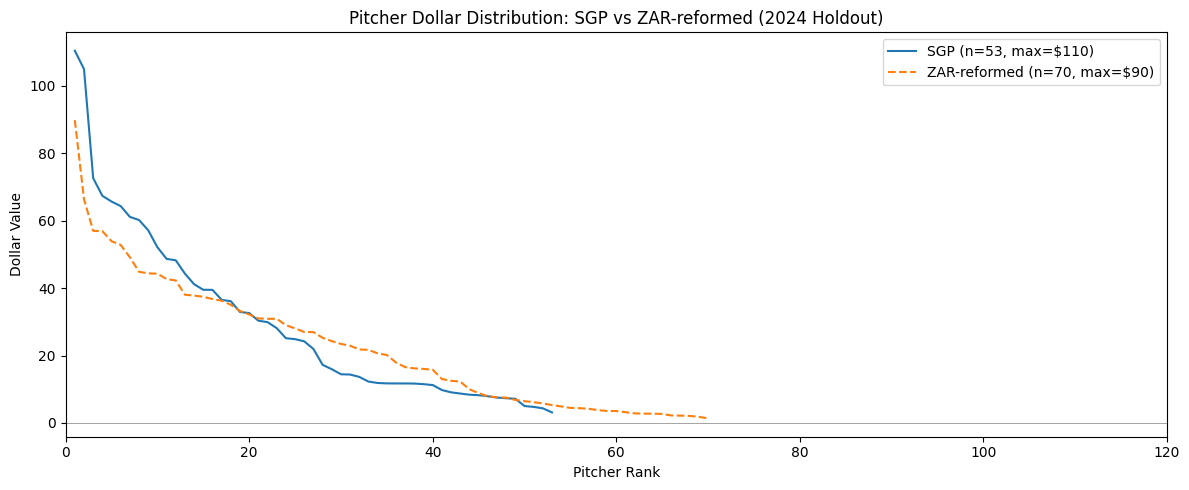

Dollar distribution summary (valued pitchers):

SGP:
  Count: 53
  Max: $110.3
  Top 10 sum: $715
  Median: $21.9
  SP count: 29, RP count: 24

ZAR:
  Count: 70
  Max: $89.8
  Top 10 sum: $559
  Median: $19.0
  SP count: 59, RP count: 11


In [12]:
# Dollar distribution comparison
fig, ax = plt.subplots(figsize=(12, 5))

for label, df, style in [
    ("SGP", sgp_pitchers[sgp_pitchers["value"] > 0].sort_values("value", ascending=False), "-"),
    ("ZAR-reformed", zar_pitchers[zar_pitchers["value"] > 0].sort_values("value", ascending=False), "--"),
]:
    values = df["value"].values
    ax.plot(range(1, len(values) + 1), values, style, label=f"{label} (n={len(values)}, max=${values[0]:.0f})")

ax.set_xlabel("Pitcher Rank")
ax.set_ylabel("Dollar Value")
ax.set_title("Pitcher Dollar Distribution: SGP vs ZAR-reformed (2024 Holdout)")
ax.legend()
ax.axhline(y=0, color="gray", linewidth=0.5)
ax.set_xlim(0, 120)
plt.tight_layout()
plt.savefig("../notebooks/sgp_dollar_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats
print("Dollar distribution summary (valued pitchers):")
for label, df in [("SGP", sgp_pitchers), ("ZAR", zar_pitchers)]:
    valued = df[df["value"] > 0]
    print(f"\n{label}:")
    print(f"  Count: {len(valued)}")
    print(f"  Max: ${valued['value'].max():.1f}")
    print(f"  Top 10 sum: ${valued.nlargest(10, 'value')['value'].sum():.0f}")
    print(f"  Median: ${valued['value'].median():.1f}")
    print(
        f"  SP count: {len(valued[valued['pitcher_type'] == 'SP'])}, RP count: {len(valued[valued['pitcher_type'] == 'RP'])}"
    )

## 9. How SGP Denominators Are Actually Computed

Let's look at the actual denominator values and what they mean for the rate-stat problem.

In [13]:
# Compute SGP denominators from Yahoo league standings
import json

standings_raw = pd.read_sql(
    """
    SELECT season, team_name, stat_values_json
    FROM yahoo_team_season_stats
    WHERE season BETWEEN 2019 AND 2024
""",
    conn,
)
standings_raw["stats"] = standings_raw["stat_values_json"].apply(json.loads)

pitch_cats = ["era", "whip", "so", "w", "sv+hld"]
for cat in pitch_cats:
    standings_raw[cat] = standings_raw["stats"].apply(lambda s, c=cat: s.get(c, 0.0))

# Compute denominator per category per season: mean gap between adjacent teams
denom_rows = []
for season, grp in standings_raw.groupby("season"):
    for cat in pitch_cats:
        vals = sorted(grp[cat].dropna().values)
        if len(vals) < 2:
            continue
        gaps = [vals[i + 1] - vals[i] for i in range(len(vals) - 1)]
        d = np.mean(gaps)
        # Negate for lower-is-better (ERA, WHIP)
        if cat in ("era", "whip"):
            d = -d
        denom_rows.append({"season": season, "category": cat, "denominator": d})

sgp_denoms = pd.DataFrame(denom_rows)
print("SGP Denominators by category and season:")
pivot = sgp_denoms.pivot_table(index="season", columns="category", values="denominator")
print(pivot[pitch_cats].round(4))

print("\nAverage denominators across seasons:")
avg_denoms = sgp_denoms.groupby("category")["denominator"].mean()
print(avg_denoms.round(4))

print("\n--- Interpretation ---")
era_denom = abs(avg_denoms.get("era", 0.15))
print(f"ERA denominator ≈ {era_denom:.3f} means one standings place ≈ {era_denom:.3f} ERA points")
print("So a pitcher with ERA 0.30 below baseline gets ~2 SGP from ERA alone")
print("This is the SAME whether they pitch 60 IP or 200 IP — that's the problem")

baseline_era = sgp_pitchers["proj_era"].median()
print(f"\nExample: reliever (60 IP, ERA 2.80) vs starter (180 IP, ERA 3.50):")
print(f"  Baseline ERA ≈ {baseline_era:.2f}")
rp_era_sgp = (baseline_era - 2.80) / era_denom
sp_era_sgp = (baseline_era - 3.50) / era_denom
print(f"  Reliever ERA SGP: ({baseline_era:.2f} - 2.80) / {era_denom:.3f} = {rp_era_sgp:.1f}")
print(f"  Starter  ERA SGP: ({baseline_era:.2f} - 3.50) / {era_denom:.3f} = {sp_era_sgp:.1f}")
print(f"  SGP says the reliever is BETTER at ERA by {rp_era_sgp - sp_era_sgp:.1f} SGP")
print(f"  But the starter pitches 3x the innings, contributing 3x more to the team's ERA!")

SGP Denominators by category and season:
category     era    whip       so       w  sv+hld
season                                           
2019     -0.0900 -0.0123  25.6154  2.7692  0.0000
2020     -0.1418 -0.0273  18.7273  1.7273  0.0000
2021     -0.1109 -0.0245  30.6364  2.8182  9.3636
2022     -0.0677 -0.0131  33.0769  2.8462  8.0000
2023     -0.0785 -0.0169  34.5385  2.8462  8.6923
2024     -0.0538 -0.0092  29.2308  2.5385  7.8462

Average denominators across seasons:
category
era       -0.0905
so        28.6375
sv+hld     5.6503
w          2.5909
whip      -0.0172
Name: denominator, dtype: float64

--- Interpretation ---
ERA denominator ≈ 0.090 means one standings place ≈ 0.090 ERA points
So a pitcher with ERA 0.30 below baseline gets ~2 SGP from ERA alone
This is the SAME whether they pitch 60 IP or 200 IP — that's the problem

Example: reliever (60 IP, ERA 2.80) vs starter (180 IP, ERA 3.50):
  Baseline ERA ≈ 4.18
  Reliever ERA SGP: (4.18 - 2.80) / 0.090 = 15.2
  Starter  ERA

## 10. Summary & Next Steps

**Findings:**
1. SGP rate-stat scores (ERA, WHIP) have zero correlation with IP — a reliever with great rates gets the same credit as a workhorse starter
2. ZAR naturally handles this via `(rate - baseline) * IP` marginal contributions
3. Simple IP-weighting of SGP rate stats significantly improves the SP/RP balance
4. The denominator distortion is the primary driver of SGP's near-zero pitcher WAR correlation

**Potential fixes (ranked by complexity):**
1. **IP-weighted rate SGP** — multiply rate-stat SGP by `IP / avg_IP`. Simple, preserves SGP framework
2. **Marginal-contribution SGP** — convert rate stats to IP-weighted contributions *before* dividing by denominator. More principled but changes what the denominator means
3. **Separate SP/RP pools** — compute SGP within each pool separately. Avoids the mixed-pool problem entirely but requires defining pool membership

**Relationship to optimal assignment:**
- The assignment fix (flex-slot solver) and the denominator fix are orthogonal
- Assignment fixes *how many* pitchers get valued; denominators fix *which* pitchers rank highest
- Both are needed for SGP to be competitive with ZAR